# FNO for PDEs — Part 2: 2D Navier-Stokes, train + experiments (Colab)

Trains FNO2d and a U-Net2d baseline, then runs all four experiments (accuracy,
resolution transfer, rollout stability, speed) in one session on the GPU.

**Before running:** Runtime -> Change runtime type -> **T4 GPU**, then Run all.


## 1. Clone and install

In [2]:
!git clone https://github.com/amark-23/fno-pde.git
%cd fno-pde
!pip install -q -r requirements.txt
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


Cloning into 'fno-pde'...
remote: Enumerating objects: 217, done.
remote: Counting objects: 100% (217/217), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 217 (delta 79), reused 161 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (217/217), 1.34 MiB | 13.81 MiB/s, done.
Resolving deltas: 100% (79/79), done.
/content/fno-pde/fno-pde
GPU: Tesla T4


## 2. Get the dataset (from Drive, or regenerate on GPU)

In [3]:
import os, numpy as np
DATA = "data/navier_stokes.npz"; os.makedirs("data", exist_ok=True)
try:
    from google.colab import drive; drive.mount('/content/drive')
    src = "/content/drive/MyDrive/navier_stokes.npz"
    if os.path.exists(src):
        import shutil; shutil.copy(src, DATA); print("loaded from Drive")
except Exception as e:
    print("Drive skip:", e)
if not os.path.exists(DATA):
    from src.solvers.navier_stokes_torch import generate_dataset
    print("generating..."); d = generate_dataset(n_traj=1000, N=64, nu=1e-3, dt=1e-3, t_final=15.0, n_snapshots=20, seed=0)
    np.savez_compressed(DATA, vorticity=d); print("generated", d.shape)
print("dataset:", np.load(DATA)["vorticity"].shape)


Mounted at /content/drive
loaded from Drive
dataset: (1000, 20, 64, 64)


## 3. Load train/test and helpers

In [4]:
import time
from src.data_ns import load_ns, make_loader, add_coords, single_step_pairs
from src.metrics import relative_l2
device = "cuda" if torch.cuda.is_available() else "cpu"

(x_tr, y_tr), (x_te, y_te), (x_norm, y_norm) = load_ns(DATA, n_train_traj=800, n_test_traj=200)
print("train pairs:", x_tr.shape[0], "| test pairs:", x_te.shape[0])

def predict(model, x, bs=64):
    model.eval(); outs=[]
    with torch.no_grad():
        for i in range(0, len(x), bs):
            outs.append(model(x[i:i+bs].to(device)).cpu())
    return torch.cat(outs)

def train(model, epochs=50, lr=1e-3, bs=32):
    model = model.to(device)
    loader = make_loader(x_tr, y_tr, batch_size=bs)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=max(1,epochs//2), gamma=0.5)
    t0=time.time()
    for ep in range(epochs):
        model.train(); tot=nb=0
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            opt.zero_grad(); loss=relative_l2(model(xb),yb); loss.backward(); opt.step()
            tot+=loss.item(); nb+=1
        sched.step()
        if (ep+1)%max(1,epochs//10)==0: print(f"  epoch {ep+1}/{epochs}  train rel-L2 {tot/nb:.4f}")
    err = relative_l2(y_norm.decode(predict(model, x_te)), y_te).item()
    print(f"  test rel-L2 {err:.4f} | params {sum(p.numel() for p in model.parameters()):,} | {time.time()-t0:.0f}s")
    return model, err


train pairs: 15200 | test pairs: 3800


## 4. Train FNO2d and U-Net2d (Experiment 1: accuracy)

In [5]:
from src.models.fno import FNO2d
from src.models.unet import UNet2d
print("FNO2d:");  fno,  fno_err  = train(FNO2d(modes1=12, modes2=12, width=32, depth=4))
print("U-Net2d:"); unet, unet_err = train(UNet2d(in_channels=3, out_channels=1, width=24, n_levels=3))
print(f"\nAccuracy (single-step):  FNO {fno_err:.4f}   U-Net {unet_err:.4f}")


FNO2d:
  epoch 5/50  train rel-L2 0.0650
  epoch 10/50  train rel-L2 0.0577
  epoch 15/50  train rel-L2 0.0552
  epoch 20/50  train rel-L2 0.0541
  epoch 25/50  train rel-L2 0.0531
  epoch 30/50  train rel-L2 0.0496
  epoch 35/50  train rel-L2 0.0491
  epoch 40/50  train rel-L2 0.0488
  epoch 45/50  train rel-L2 0.0487
  epoch 50/50  train rel-L2 0.0484
  test rel-L2 0.0475 | params 1,188,353 | 711s
U-Net2d:
  epoch 5/50  train rel-L2 0.0537
  epoch 10/50  train rel-L2 0.0459
  epoch 15/50  train rel-L2 0.0426
  epoch 20/50  train rel-L2 0.0398
  epoch 25/50  train rel-L2 0.0387
  epoch 30/50  train rel-L2 0.0338
  epoch 35/50  train rel-L2 0.0333
  epoch 40/50  train rel-L2 0.0327
  epoch 45/50  train rel-L2 0.0327
  epoch 50/50  train rel-L2 0.0321
  test rel-L2 0.0326 | params 1,134,721 | 967s

Accuracy (single-step):  FNO 0.0475   U-Net 0.0326


## 5. Experiment 2: resolution transfer

FNO {32: 0.039, 64: 0.0475, 128: 0.043}
U-Net {32: 0.2822, 64: 0.0326, 128: 0.1487}


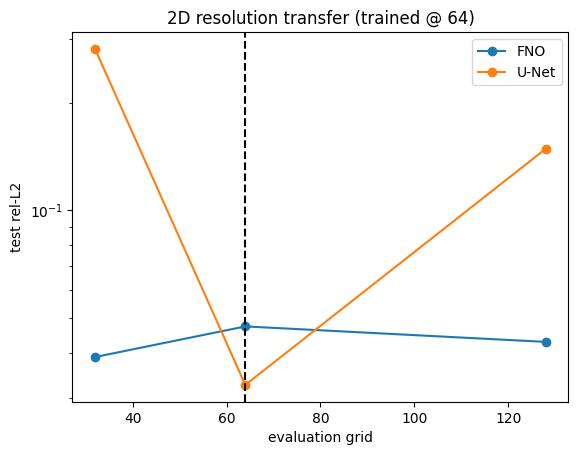

In [6]:
import matplotlib.pyplot as plt
from src.experiments_ns import downsample_2d
from src.solvers.navier_stokes_torch import generate_dataset as gen2d

def eval_traj(model, vort):
    xp, yp = single_step_pairs(vort)
    pred = y_norm.decode(predict(model, add_coords(x_norm.encode(xp))))
    return relative_l2(pred, yp).item()

raw64  = torch.from_numpy(np.load(DATA)["vorticity"]).float()[800:1000]     # native test
raw32  = downsample_2d(raw64, 32)
raw128 = torch.from_numpy(gen2d(n_traj=50, N=128, nu=1e-3, dt=1e-3, t_final=15.0, n_snapshots=20, seed=999)).float()

res = {32:raw32, 64:raw64, 128:raw128}
curves = {"FNO":{}, "U-Net":{}}
for name, model in [("FNO", fno), ("U-Net", unet)]:
    for r, v in res.items():
        curves[name][r] = eval_traj(model, v)
    print(name, {r: round(curves[name][r],4) for r in [32,64,128]})

for name in curves:
    plt.plot([32,64,128], [curves[name][r] for r in [32,64,128]], "-o", label=name)
plt.axvline(64, ls="--", color="k"); plt.yscale("log")
plt.xlabel("evaluation grid"); plt.ylabel("test rel-L2"); plt.title("2D resolution transfer (trained @ 64)"); plt.legend(); plt.show()


## 6. Experiment 3: autoregressive rollout

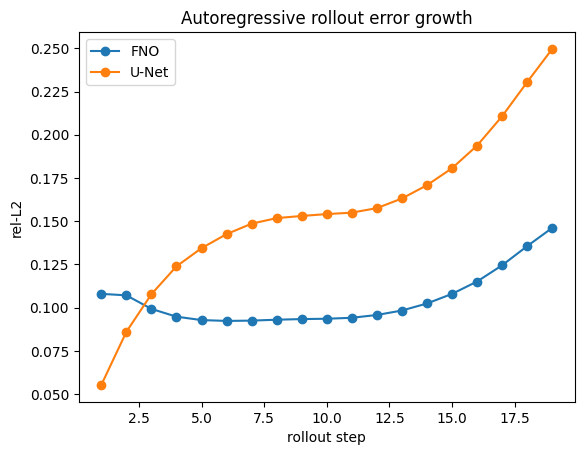

In [7]:
from src.experiments_ns import rollout
raw = torch.from_numpy(np.load(DATA)["vorticity"]).float()[800:820]   # 20 test trajectories
w0, true = raw[:,0], raw[:,1:]
n_steps = true.shape[1]

def rollout_err(model):
    pred = rollout(model, w0, n_steps, x_norm, y_norm, device=device)   # (20, n_steps, 64,64)
    errs=[]
    for s in range(n_steps):
        num=(pred[:,s]-true[:,s]).reshape(20,-1).norm(dim=1); den=true[:,s].reshape(20,-1).norm(dim=1)
        errs.append((num/den).mean().item())
    return errs

for name, model in [("FNO", fno), ("U-Net", unet)]:
    plt.plot(range(1,n_steps+1), rollout_err(model), "-o", label=name)
plt.xlabel("rollout step"); plt.ylabel("rel-L2"); plt.title("Autoregressive rollout error growth"); plt.legend(); plt.show()


## 7. Experiment 4: speed (FNO vs solver)

In [8]:
from src.solvers.navier_stokes_torch import solve_ns
def sync():
    if device=="cuda": torch.cuda.synchronize()

N, B = 64, 50
w = torch.randn(B, N, N, device=device)
save_every = 750                          # one recorded snapshot = 750 solver substeps (t_final/dt/n_snapshots)

_ = solve_ns(w, nu=1e-3, dt=1e-3, t_final=save_every*1e-3, save_every=save_every); sync()
t0=time.time()
for _ in range(3): solve_ns(w, nu=1e-3, dt=1e-3, t_final=save_every*1e-3, save_every=save_every)
sync(); solver_t=(time.time()-t0)/3

x = add_coords(x_norm.encode(w.cpu().unsqueeze(-1))).to(device)
fno.eval()
with torch.no_grad():
    for _ in range(5): fno(x)
    sync(); t0=time.time()
    for _ in range(20): fno(x)
    sync(); fno_t=(time.time()-t0)/20
print(f"solver one snapshot-step: {solver_t*1e3:.1f} ms | FNO one step: {fno_t*1e3:.1f} ms | speedup {solver_t/fno_t:.0f}x")


solver one snapshot-step: 427.1 ms | FNO one step: 15.8 ms | speedup 27x


## Summary
- Accuracy: FNO2d vs U-Net2d single-step error.
- Resolution transfer: FNO stays flat across grids; U-Net degrades off its training grid.
- Rollout: error growth over autoregressive steps.
- Speed: FNO forward pass vs the numerical solver.

Fill these into the Part 2 table in the README.
